In [128]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import ast

In [129]:
pd.set_option('display.max_columns', None)

# Начало

Для начала я скажу, что буду работать с основным датасетом `hh.csv`, его будем использовать, чтобы поработать с текстовыми данными. Это наверное самое сложное в датасете, название, описание. В данном ноутбуке, который является составной часть ГП-2 мы будем делать кодирование текстовой информации и далее кластеризацию полученных векторных предсавлений вакансий.

In [ ]:
df_hh = pd.read_csv("data/hh.csv", index_col=0)
df_sj = pd.read_csv("data/superjob.csv", index_col=0)

In [145]:
df_hh.info()

<class 'pandas.DataFrame'>
RangeIndex: 10294 entries, 0 to 10293
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   id             10294 non-null  int64
 1   url            10294 non-null  str  
 2   name           10294 non-null  str  
 3   salary         3158 non-null   str  
 4   description    10294 non-null  str  
 5   skills         10294 non-null  str  
 6   company        10294 non-null  str  
 7   address        10294 non-null  str  
 8   area           10294 non-null  str  
 9   experience     10290 non-null  str  
 10  employment     10290 non-null  str  
 11  schedule       10092 non-null  str  
 12  working_hours  10187 non-null  str  
 13  work_format    9809 non-null   str  
 14  published_at   10294 non-null  str  
 15  archived       10294 non-null  bool 
 16  source         10294 non-null  str  
dtypes: bool(1), int64(1), str(15)
memory usage: 46.3 MB


In [131]:
df_hh.sample(5)

,id,url,name,salary,description,skills,company,address,area,experience,employment,schedule,working_hours,work_format,published_at,archived,source
9310,131676597,https://hh.ru/vacancy/131676597,Старший аналитик (отдел продаж),NaN,"Наш клиент, известная\nмеждународная компания\...","['Python', 'SQL', 'Excel', 'Power BI', 'Tablea...",ANCOR,Москва,Москва,3–6 лет,Полная занятость,5/2,8,гибрид,2026-03-30T17:08:19.600+03:00,False,hh
8471,131927548,https://hh.ru/vacancy/131927548,Аналитик по продажам и управлению данными,NaN,Обязанности:\nОбеспечивать наличие качественно...,"['Анализ рынка', 'MS Excel', 'Power Query', 'P...",Bonduelle,"Москва , Красносельская , Верхняя Красносельск...",Москва,1–3 года,Полная занятость,5/2,8,гибрид,2026-04-07T17:33:02.176+03:00,False,hh
8958,131182409,https://hh.ru/vacancy/131182409,"Риск-менеджер (рыночные риски, ликвидности)",от 120 000 ₽ за месяц до вычета налогов,О компании\nKas Capital — проп-трейдинговая ко...,"['Анализ рисков', 'SQL', 'Риск-менеджмент', 'Р...",KasCapital,"Москва, Москва",Москва,1–3 года,Полная занятость,5/2,8 или 9,удалённо,2026-04-08T18:50:21.634+03:00,False,hh
5867,131539707,https://hh.ru/vacancy/131539707,Руководитель направления развития CRM продаж,NaN,Роль предполагает управление направлением на с...,['Git'],Альфа-Банк. Центральный офис,"Москва , Технопарк , проспект Андропова, 18к6",Москва,более 6 лет,Полная занятость,5/2,8,гибрид,2026-03-25T13:01:11.616+03:00,False,hh
4427,131548557,https://hh.ru/vacancy/131548557,Аналитик,до 120 000 ₽ за месяц на руки,Наша команда занимается разработкой и поддержк...,"['XML', 'Разработка технических заданий', 'Биз...",Веб-Мост,"Москва , Красносельская , Сокольники , Русаков...",Москва,1–3 года,Полная занятость,5/2,8,"на месте работодателя, удалённо или гибрид",2026-03-25T16:10:25.037+03:00,False,hh


In [132]:
df = df_hh.copy()

df['name'] = df['name'].fillna('')
df['description'] = df['description'].fillna('')
df['skills'] = df['skills'].fillna('')

Для начала обработаем текст, приведем все к нижнему регистру, уберем все личшее, битое и тд. 

In [133]:
def clean_text(text):
    text = str(text).lower()
    text = text.replace('\n', ' ')
    text = text.replace('\t', ' ')
    text = text.replace('\r', ' ')
    
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-zа-яё0-9\s\+\#\-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

Так же обработаем `skills`, переведем из строки в список + тоже приведем к нижнему регистру

In [ ]:
def parse_skills(skills):
    if isinstance(skills, list):
        skills_new = skills
    else:
        try:
            skills_new = ast.literal_eval(skills)
        except:
            return []
    
    if not isinstance(skills_new, list):
        return []
    
    ans = []
    for skill in skills_new:
        skill = str(skill).strip().lower()
        if skill != '':
            ans.append(skill)
    
    return ans

In [135]:
df['name_clean'] = df['name'].apply(clean_text)
df['description_clean'] = df['description'].apply(clean_text)
df['skills_list'] = df['skills'].apply(parse_skills)

Скажу сразу, это не первая итерация ноутбука, в самом начале я пробывал более классические методы кодировки текста, использовал TF-IDF для `name` и `description` + one_hot для `skills`, но shape матрицы получался (10294, 15803), это слишком много, тут проклятие размерности! Никакие методы у меня в таком пространстве не работали, даже понижение не очень помогало. Так что я решил радикально поменять стратегию и прибегнуть к более продвинутым методам, но мы тут не простые же))

В итоге я решил использовать современную encoder-only модельку для векторных эмбедингов, взял небольшую/немаленькую -- embeddinggemma 300M, так как у меня Mac и делал локально, то взял веса MLX. 

Собственно чтобы делать вектор через embeddinggemma нужен единый кусок текста, решил просто склеить все три текстовых поля в одно `vacancy_text`, и уже его засовывать!

In [136]:
def build_vacancy_text(row):
    name = row['name_clean']
    description = row['description_clean']
    skills = ', '.join(row['skills_list'])
    
    text = f"""
    Название вакансии: {name}
    Навыки: {skills}
    Описание: {description}
    """
    
    return re.sub(r'\s+', ' ', text).strip()

In [137]:
df['vacancy_text'] = df.apply(build_vacancy_text, axis=1)
df[['name', 'vacancy_text']].head()

,name,vacancy_text
0,Стажер аналитик-разработчик в Яндекс,Название вакансии: стажер аналитик-разработчик...
1,Стажёр в отдел развития инструментов управлени...,Название вакансии: стажёр в отдел развития инс...
2,Стажер (количественные исследования),Название вакансии: стажер количественные иссле...
3,Бизнес-администратор SQL,Название вакансии: бизнес-администратор sql На...
4,Аналитик по продажам и управлению данными,Название вакансии: аналитик по продажам и упра...


# embeddinggemma

In [ ]:
!pip install -U torch transformers sentence-transformers accelerate 

In [117]:
import torch

print("MPS available:", torch.backends.mps.is_available())
print("MPS built:", torch.backends.mps.is_built())

MPS available: True
MPS built: True


In [14]:
!pip install mlx-embeddings

Сразу скажу, что сказать данную версию через sentence-transformers не получиться, так как тут нужен именно mlx_embeddings, тензоры MLX, долго с этим разбирался...

In [ ]:
from mlx_embeddings import load
import mlx.core as mx

model, tokenizer = load("mlx-community/embeddinggemma-300m-4bit") # и да квантованную возьму, ну а что))
# памяти не супер много

Fetching 12 files: 100%|██████████| 12/12 [00:00<00:00, 177224.11it/s]


In [118]:
import sys
print(sys.executable)

import mlx
import mlx.core as mx
print("MLX OK")
print(mx.__version__)

/Users/alexsuw/Desktop/studying/iad/.conda/bin/python
MLX OK
0.31.1


In [17]:
import mlx
import mlx.core as mx

In [ ]:
# вот наша функция которая как раз обрабатывает наши описания в векторы

def encode_texts_mlx(texts, model, tokenizer, batch_size=16): # batch_size=16 чтобы не нагружать мак
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            return_tensors='mlx'
        )

        output = model(encoded['input_ids'], encoded['attention_mask'])
        emb = output.text_embeds

        all_embeddings.append(np.array(emb))
        print(f"Processed: {min(i + batch_size, len(texts))}/{len(texts)}") # добавим отслеживание, а то может быть долго

    return np.vstack(all_embeddings)

embeddings = encode_texts_mlx(
    df['vacancy_text'].tolist(),
    model,
    tokenizer,
    batch_size=16
)

print(embeddings.shape)

Processed: 16/10294
Processed: 32/10294
Processed: 48/10294
Processed: 64/10294
Processed: 80/10294
Processed: 96/10294
Processed: 112/10294
Processed: 128/10294
Processed: 144/10294
Processed: 160/10294
Processed: 176/10294
Processed: 192/10294
Processed: 208/10294
Processed: 224/10294
Processed: 240/10294
Processed: 256/10294
Processed: 272/10294
Processed: 288/10294
Processed: 304/10294
Processed: 320/10294
Processed: 336/10294
Processed: 352/10294
Processed: 368/10294
Processed: 384/10294
Processed: 400/10294
Processed: 416/10294
Processed: 432/10294
Processed: 448/10294
Processed: 464/10294
Processed: 480/10294
Processed: 496/10294
Processed: 512/10294
Processed: 528/10294
Processed: 544/10294
Processed: 560/10294
Processed: 576/10294
Processed: 592/10294
Processed: 608/10294
Processed: 624/10294
Processed: 640/10294
Processed: 656/10294
Processed: 672/10294
Processed: 688/10294
Processed: 704/10294
Processed: 720/10294
Processed: 736/10294
Processed: 752/10294
Processed: 768/1029

Ура! 15 минут ожидания и все вектора готовы, размерность каждого из коробки у данной модели 768. В принципе ок, стандарт для нас, но давайте попробуем еще сократить размерность, так как у нас очень ограниченный домен, то большинство направлений будут не информативными.


Теперь как раз попробуем сжать данные которые у нас получились, тут конечно можно подумать сразу же про PCA, но у данного алгоритма есть несколько проблем, да и на теста которые я делал работал не идеально. А я знал что есть куча других моделей, например нелинейных t-SNE. Но решил тут пойти дальше, и применил один из самых современных алгоритмов под названием `UMAP` (он совсем свежий, 2018 год!). Я пчитал про него вот [ССЫЛКА](https://habr.com/ru/companies/newprolab/articles/350584/), работает сложно, какие то графы, но главное что он может сильно лучше работать со сложной гиометрией пространства. 

Прикладываю сравнение на примере MNIST, PCA точно делали по моему на семе, вот смотрите как круто работает UMAP))

![Картинка про UMAP](https://habrastorage.org/r/w1560/getpro/habr/upload_files/73b/4cc/f9b/73b4ccf9b7a275823ee49d3f83b1c786.png)


In [ ]:
import umap
import hdbscan

umap_20 = umap.UMAP(
    n_components=20,
    n_neighbors=15,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

# гиперпараметры честно где то посмотрел, уже ссылку на найду наверное
# но главное, мы тут берем 768 -> 20 о как))

embeddings_umap_20 = umap_20.fit_transform(embeddings)

# DBSCAN c ИАДа нам вещь уже знакомая, но как вы поняли тут я изучаю новые шутки, а не просто делаю ГП
# так что я беру HDBSCAN который работает схоже,
# но строить иерархическое дерево классов, более устойчив к гиперпараметрам, это я сам проверил,
# так как много игрался с ними
# + он хорошо сочетается с UMAP )) 

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=150,
    min_samples=50,
    cluster_selection_method='eom',
    cluster_selection_epsilon=0.3
)

df['cluster_hdbscan_emb'] = clusterer.fit_predict(embeddings_umap_20)
df['cluster_hdbscan_emb'].value_counts().sort_index()

/Users/alexsuw/Desktop/studying/iad/.conda/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



cluster_hdbscan_emb
-1     2787
 0      798
 1      182
 2      790
 3     1128
 4      189
 5      550
 6     1153
 7      615
 8      162
 9      299
 10     390
 11     394
 12     687
 13     170
Name: count, dtype: int64

Далее я рисовал сначала 2d картинки, но решил в итоге использовать plotly, и это сразу помогло понимать, 3d в данном случае было сильно удобнее. 

In [ ]:
import plotly.express as px

# тут делаем 3d пространство
embeddings_3d = umap.UMAP(
    n_components=3,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42
).fit_transform(embeddings)

plot_3d = pd.DataFrame({
    'x': embeddings_3d[:, 0],
    'y': embeddings_3d[:, 1],
    'z': embeddings_3d[:, 2],
    'cluster_hdbscan': df['cluster_hdbscan_emb'].apply(lambda x: 'Noise' if x == -1 else f'Cluster {x}'),
    'name': df['name'],
    'skills': df['skills_list'].apply(lambda x: ', '.join(x[:10]))
})

fig_hdbscan = px.scatter_3d(
    plot_3d,
    x='x',
    y='y',
    z='z',
    color='cluster_hdbscan',
    hover_data=['name'],
    title='UMAP 3D — HDBSCAN'
)
fig_hdbscan.update_traces(marker=dict(size=3, opacity=0.7))

fig_hdbscan.write_html("hdbscan_umap_3d.html", auto_open=True)

/Users/alexsuw/Desktop/studying/iad/.conda/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


# Интерпретация кластеров

In [ ]:
df_export = df.copy()
lines = []

clusters = sorted([c for c in df_export['cluster_hdbscan_emb'].unique() if c != -1])

for cluster_id in clusters:
    cluster_df = df_export[df_export['cluster_hdbscan_emb'] == cluster_id].copy()
    sample_df = cluster_df.sample(n=10, random_state=1545342)

    lines.append("=" * 100)
    lines.append(f"CLUSTER {cluster_id}")
    lines.append("=" * 100)
    lines.append("")

    for _, row in sample_df.iterrows():
        vacancy_text = row['vacancy_text']
        lines.append("{")
        lines.append(f"  vacancy_text: '{vacancy_text}'")
        lines.append("}")
        lines.append("")

    lines.append("")

output_name = "clusters_vacancy_text.txt"

with open(output_name, "w", encoding="utf-8") as f:
    f.write("\n".join(lines))

In [141]:
# прогнав через ГПТ + посмотрев ручками можем дать примерные названия кластерам
# PS круто что осмысленные названия можно подобрать, в каких то случаях даже думать над названием не надо было

cluster_names = {
    -1: "Noise", # стоковое название
    0: "Marketplaces",
    1: "Internships",
    2: "1C",
    3: "Systems Analytics",
    4: "Risk Analytics",
    5: "ML/DS",
    6: "Data & Analytics",
    7: "Marketing & Operations",
    8: "Growth / Marketing Leadership",
    9: "Product Analytics",
    10: "Demand & Commercial Analytics",
    11: "Product & Market Research",
    12: "Finance",
    13: "Government"
}

In [ ]:
# теперь делаем название красивое
df["cluster_name"] = df["cluster_hdbscan_emb"].map(cluster_names)

In [143]:
df.sample(5)

,id,url,name,salary,description,skills,company,address,area,experience,employment,schedule,working_hours,work_format,published_at,archived,source,name_clean,description_clean,skills_list,vacancy_text,cluster_hdbscan_emb,cluster_name
648,130330489,https://hh.ru/vacancy/130330489,Аналитик C&amp;B (HR-аналитик),NaN,Общество с Ограниченной Ответственностью «Унив...,"['Excel', 'Git']",Media Instinct Group,"Москва , Молодежная , Ярцевская улица, 19",Москва,1–3 года,Полная занятость,5/2,8,на месте работодателя,2026-03-31T10:51:54.002+03:00,False,hh,аналитик c amp b hr-аналитик,общество с ограниченной ответственностью униве...,"[excel, git]",Название вакансии: аналитик c amp b hr-аналити...,-1,Noise
8281,131790464,https://hh.ru/vacancy/131790464,Продуктовый аналитик в Шопинг,NaN,"Шопинг\n— группа лайфстайл-сервисов, которая д...","['Python', 'SQL', 'Pandas', 'NumPy', 'SciPy', ...",Т-Банк. ИТ. Аналитика,"Москва , Белорусская , Белорусская , улица Гру...",Москва,1–3 года,Полная занятость,5/2,8,удалённо или гибрид,2026-04-02T15:31:37.299+03:00,False,hh,продуктовый аналитик в шопинг,шопинг n группа лайфстайл-сервисов которая дае...,"[python, sql, pandas, numpy, scipy, tableau, git]",Название вакансии: продуктовый аналитик в шопи...,9,Product Analytics
4350,129884309,https://hh.ru/vacancy/129884309,Экономист-аналитик,NaN,Чем Вам предстоит заниматься:\nРабота с массив...,"['Производственное планирование', 'ABC-анализ'...",Восток-Сервис,"Москва , Нижегородская , 2-й Грайвороновский п...",Москва,1–3 года,Полная занятость,5/2,8,на месте работодателя,2026-03-30T11:01:49.919+03:00,False,hh,экономист-аналитик,чем вам предстоит заниматься nработа с массива...,"[производственное планирование, abc-анализ, ан...",Название вакансии: экономист-аналитик Навыки: ...,12,Finance
7841,129343220,https://hh.ru/vacancy/129343220,Главный специалист отдела аналитического монит...,NaN,Обязанности:\nСбор и систематизация информации...,['Git'],Сахалинская Энергия,"Москва , Баррикадная , Краснопресненская , Смо...",Москва,более 6 лет,Полная занятость,5/2,8,на месте работодателя,2026-03-14T10:41:20.166+03:00,False,hh,главный специалист отдела аналитического монит...,обязанности nсбор и систематизация информации ...,[git],Название вакансии: главный специалист отдела а...,-1,Noise
6335,131665271,https://hh.ru/vacancy/131665271,Экономист/Финансовый аналитик,от 136 000 до 150 000 ₽ за месяц до вычета нал...,Агрохолдинг Белая Дача - флагман категории мыт...,"['Excel', 'Git']",Агрохолдинг Белая Дача,"Котельники , Котельники , Яничкин проезд, 4",Котельники,1–3 года,Полная занятость,5/2,8,на месте работодателя,2026-04-03T17:15:16.425+03:00,False,hh,экономист финансовый аналитик,агрохолдинг белая дача - флагман категории мыт...,"[excel, git]",Название вакансии: экономист финансовый аналит...,12,Finance


In [ ]:
# для удобства решил почистить муссор
df = df.drop(columns=['name', 'description', 'skills', 'url', 'area', 'source'])
df.sample(5)

,id,salary,company,address,experience,employment,schedule,working_hours,work_format,published_at,archived,name_clean,description_clean,skills_list,vacancy_text,cluster_hdbscan_emb,cluster_name
5520,131438168,NaN,Газпромбанк,"Москва , Павелецкая , Третьяковская , Третьяко...",1–3 года,Полная занятость,5/2,8,на месте работодателя,2026-03-22T19:30:38.330+03:00,False,финансовый аналитик гонконг,company na boutique financial services a part ...,"[excel, git]",Название вакансии: финансовый аналитик гонконг...,12,Finance
9482,130759087,NaN,VVP Group,"Москва, Москва",не требуется,Полная занятость,5/2,8,на месте работодателя или гибрид,2026-03-27T14:59:36.123+03:00,False,бизнес аналитик,ищем бизнес аналитика который хорошо разбирает...,"[sql, git]",Название вакансии: бизнес аналитик Навыки: sql...,2,1C
8058,131264463,от 190 000 до 220 000 ₽ за месяц до вычета нал...,РЕАЛИСТ БАНК,"Москва , Кузнецкий мост , Сухаревская , Трубна...",3–6 лет,Полная занятость,5/2,8,на месте работодателя или гибрид,2026-03-16T15:23:23.589+03:00,False,главный специалист - риск менеджер юл,декретная ставка nищете работу где ваш аналити...,"[590-п, 611-п]",Название вакансии: главный специалист - риск м...,4,Risk Analytics
8405,131705712,NaN,Авилон Автомобильная Группа,"Москва , Новохохловская , Новохохловская , Тек...",более 6 лет,Полная занятость,5/2,8,на месте работодателя,2026-04-07T14:18:50.185+03:00,False,руководитель направления видеоаналитики,мы предлагаем nофициальное трудоустройство в а...,[git],Название вакансии: руководитель направления ви...,3,Systems Analytics
6354,130103346,NaN,"Банк ПСБ, Старт карьеры","Москва , Павелецкая , Дербеневская набережная, 7",не требуется,Полная занятость,5/2 или свободный,6 или 8,на месте работодателя,2026-04-08T14:10:34.460+03:00,False,стажёр-дизайнер продукта,ключевые задачи nпроектировать интерфейсы для ...,[figma],Название вакансии: стажёр-дизайнер продукта На...,-1,Noise


Теперь давайте все таки сделаем 2d картинку и подпишем на ней названия наши новые!

In [151]:
embeddings_2d = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42
).fit_transform(embeddings)

clusters = df["cluster_hdbscan_emb"].values

/Users/alexsuw/Desktop/studying/iad/.conda/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



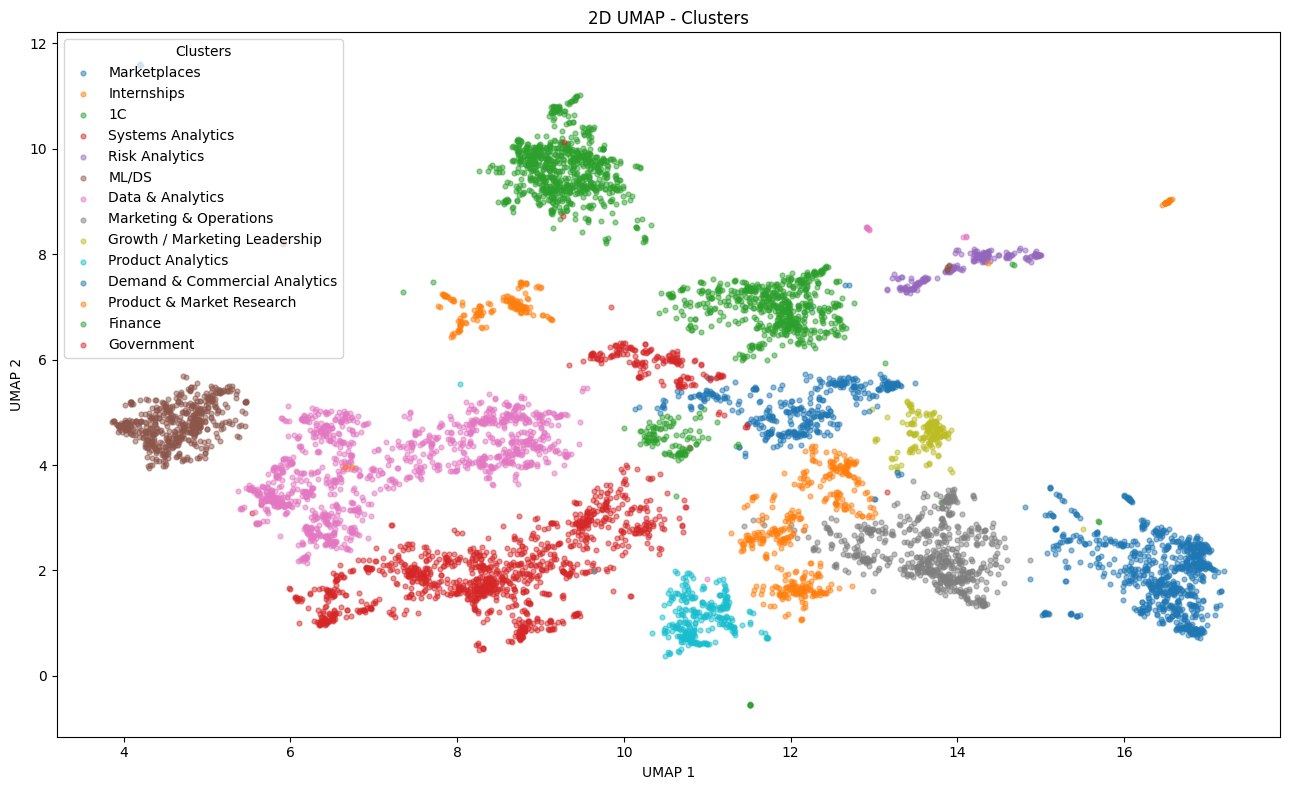

In [ ]:
plt.figure(figsize=(13, 8))

for cluster_id in sorted(set(clusters)):
    if cluster_id == -1:
        continue
    # данную визуализацию я делаю без шума, чтобы было более наглядно
    # шум в данном случае это с одной стороны "выбросы", но чаще всего это значения между кластерами
    # но нам в том числе говорит о плавности перехода от например бизнес аналитика, до системного
    # грани прямой нет, есть промежуток

    mask = clusters == cluster_id
    label = cluster_names.get(cluster_id, f"Cluster {cluster_id}")

    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        alpha=0.5,
        s=12,
        label=label
    )

plt.title("UMAP 2D - Сlusters")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="Clusters")
plt.tight_layout()
plt.show()

## Выводы по анализу текстовых данных 

Сразу скажу что здесь будет не все, так как говорить можно очень долго, самые интересные выводы и бизнес инсайты оставлю на защиту))

- С помощью выше описанного инструментария получилось очень даже не плохо)) так что считаю это победой
- Даже после подбора гиперпараметров `noise` составляет значительную часть данных (немногим менее 30%), и я здесь не считаю это проблемой! Можно было лучше?, наверно.
- "Шум" в основном находиться между кластерами, это вообще очень круто получилось, геометрия пространства в итоге получилась с явными отдельными кластерами (например маркетплейсы и 1С) и с другой стороны менее различимыми.
- Получилось так, что спускаясь по кластеру вниз или вверх мы по факту увеличиваем или уменьшаем степень тех хардов в работе
- Наш метод сбора данных тоже не плохой, у нас действительно датасет про аналитиков, а не про уборзиков например. есть конечно другие, например разработчик Java, но он рядом с самыми хардовыми дата инженерами так что и ладно)
- Из расположения данных видно, что аналитики это супер разнообразная группа подпрофессий, аналитик это не пойми кто, он может быть совсем разным специалистом
- Разные виды аналитиков плавно перетекают друг в друга
- Можно например с уверенностью сказать, что в области аналитки есть очень разные требования, вакансии и это делает аналитику и анализ данных очень перспективными, так как все больше людей могут найти что то интересным для себя

Вот так примерно)) на скорую руку честно, простите!

In [ ]:
# сделаем красивую версию
# файлы приложу в гитхаб

plot_3d_clusters = pd.DataFrame({
    'x': embeddings_3d[:, 0],
    'y': embeddings_3d[:, 1],
    'z': embeddings_3d[:, 2],
    'cluster_name': df['cluster_name'],
    'name': df['name_clean'],
    'skills': df['skills_list'].apply(lambda x: ', '.join(x[:10]))
})

fig_hdbscan = px.scatter_3d(
    plot_3d_clusters,
    x='x',
    y='y',
    z='z',
    color='cluster_name',
    hover_data=['name'],
    title='UMAP 3D — Clusters'
)
fig_hdbscan.update_traces(marker=dict(size=3, opacity=0.7))

fig_hdbscan.write_html("clusters_umap_3d.html", auto_open=True)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [ ]:
# еще кстати решил пожалеть вас, если вдруш вам понадобятся исходные мои векторы эмбедингов, 
# то подготовил файлик embeddings.csv, он слишком большой, так что закину его через гугл диск
# ссылка: https://drive.google.com/file/d/1IjeBYDZM1bqVSz5MxiXyZYvG82znNOwY/view?usp=sharing



# Анализ зарплат

Теперь хочется еще поанализировать такую шутку как зарплаты, это тоже не самая простая часть исследования, так как она находиться в очень странном формате. Но мы попробуем))

In [163]:
df['salary'].describe()

count                              3158
unique                              640
top       от 150 000 ₽ за месяц на руки
freq                                126
Name: salary, dtype: object

In [164]:
df.shape

(10294, 17)

Тут мы видим первую проблему! зарплаты есть только у 30% наших данных, и с этим мы никак не поборимся, это реалии рынка IT и других. Поэтому будем смотреть на те в которых есть данные, но удостоверимся что данные о ЗП примерно одинаково распределены по пространсву наших аналитиков, для этого можем посчитать долю просто в найденных выше кластерах (% nan)

In [166]:
df.groupby("cluster_name")["salary"].apply(lambda x: x.isna().mean() * 100).sort_values(ascending=False)

cluster_name
Product Analytics                91.973244
ML/DS                            90.363636
Data & Analytics                 84.735473
Risk Analytics                   84.126984
Growth / Marketing Leadership    80.864198
Internships                      76.923077
Noise                            74.991030
Systems Analytics                74.645390
Demand & Commercial Analytics    74.358974
Product & Market Research        70.050761
1C                               64.683544
Finance                          63.609898
Government                       57.058824
Marketing & Operations           44.065041
Marketplaces                     17.919799
Name: salary, dtype: float64

А это интересно, данные о ЗП практически полностью отсутсвуют в категориях продуктовой аналитики, ML/DS и других. А вот в 1С или гос компаниях почти половина уже с раскрытыми данными о зарплате. И есть победитель -- это маркетплейны, там всего 17% не имеют данных о ЗП. 

Могу выдвинуть несколько идей на этот счет: 
- вакансии где есть разные грейды, совсем разный уровень подготовки и метча кандидата, то там нет данных о ЗП, так как они сильно зависят от самого кандидата
- чем более высокооплачиваемая сфера, тем меньше данные о ЗП, может чтобы не пугать простых смертных на hh, кто случайно зашел на вакансию продуктового аналитика

Дальше анализировать ЗП конечно можно, я даже придумал как, и поэксперементировал (можно убрать все числа, убрать личшние пробелы, и получиться что есть всего несколько шаблонов, упрощая или от X или до X или от X до Y). Но я это делать не буду, не вижу смысла особо, тратить много времени на то, что не сильно репрезентативно, для большинсва категорий. 